In [1]:
import tensorflow as tf
import keras
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import time

In [2]:
plt.rcParams['font.sans-serif'] = ['Simhei']   #用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] =  False    #用来正常显示负号

import os
import time
pd.set_option('display.max_columns', 999)    #设置数据展示的最大列数和最大行数
pd.set_option('display.max_rows', 500)

In [3]:
df= pd.read_csv('data-14-01_datawash.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41464 entries, 0 to 41463
Columns: 237 entries, COPAY_PCT to PROV_LEVEL_非医保
dtypes: bool(142), float64(8), int64(87)
memory usage: 35.7 MB


In [4]:
df.describe()

,COPAY_PCT,CWF_AMT_DAY,INVOICE_CNT,POLICY_CNT,ORG_PRES_AMT_VALUE,APP_AMT,REJECTED_AMT,SUB_AMT,CL_SOCIAL_PAY_AMT,CL_THIRD_PARTY_PAY_AMT,CL_OWNER_PAY_AMT,CL_SELF_CAT_PAY_AMT,FRAUD,R680,W410,M121,W056,R625,R270,R140,R605,W210,R540,M143,W057,R600,T250,R260,M149,W280,M107,W360,M118,W090,W080,W260,W190,R682,R010,W250,W290,W010,W200,W220,M029,W100,T420,W340,M111,R180,T460,R040,R130,M117,M155,R100,W050,M120,T180,M144,W105,M116,M009,W120,W270,W055,R170,W390,M002,M123,R658,M109,M113,R530,M114,W040,W070,M110,W310,R520,T450,T190,M119,M101,W380,R030,W400,M004,R610,R542,W230,W180,M060,R060,W020
count,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000
mean,7.411152,2.894390,7.769390,1.006584,1.310236,0.877129,0.046557,1.721675,-1.150648,-2.988872,-1.467993,-2.524729,0.082771,0.000048,0.000241,0.000265,0.004196,0.000024,0.000024,0.000193,0.000386,0.000096,0.000941,0.000145,0.001085,0.000531,0.000048,0.000024,0.000048,0.012734,0.000024,0.000796,0.000072,0.000048,0.309063,0.003328,0.062922,0.000048,0.000289,0.000362,0.018860,0.000024,0.318662,0.061837,0.000121,0.022501,0.000024,0.000024,0.000048,0.000072,0.000145,0.000048,0.000048,0.000096,0.000048,0.000072,0.001857,0.000024,0.016979,0.000048,0.009575,0.002870,0.000024,0.000048,0.125506,0.416699,0.000265,0.000555,0.000072,0.000072,0.016448,0.000024,0.000048,0.689683,0.000096,0.004631,0.001447,0.000289,0.000048,0.015435,0.000024,0.000024,0.000169,0.000048,0.000241,0.000121,0.000482,0.000121,0.001447,0.000024,0.007959,0.001857,0.000145,0.010612,0.000338
std,4.730610,2.592051,9.570459,0.080875,1.106645,1.456082,1.922337,0.716909,2.284732,0.233771,1.857563,1.336112,0.275538,0.006945,0.015528,0.016286,0.064644,0.004911,0.004911,0.013889,0.019640,0.009822,0.030655,0.012029,0.032926,0.023029,0.006945,0.004911,0.006945,0.112125,0.004911,0.028200,0.008506,0.006945,0.462113,0.057595,0.242826,0.006945,0.017010,0.019017,0.136031,0.004911,0.465963,0.240862,0.010981,0.148309,0.004911,0.004911,0.006945,0.008506,0.012029,0.006945,0.006945,0.009822,0.006945,0.008506,0.043054,0.004911,0.129193,0.006945,0.097381,0.053496,0.004911,0.006945,0.331296,0.493018,0.016286,0.023546,0.008506,0.008506,0.127192,0.004911,0.006945,0.462629,0.009822,0.067891,0.038013,0.017010,0.006945,0.123277,0.004911,0.004911,0.012992,0.006945,0.015528,0.010981,0.021957,0.010981,0.038013,0.004911,0.088857,0.043054,0.012029,0.102466,0.018372
min,1.000000,1.000000,1.000000,1.000000,-3.000000,-3.000000,-3.000000,-3.000000,-3.000000,-3.000000,-3.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00

In [5]:
# APP_AMT PAY_AMT REJECTED_AMT
df.drop(columns=['APP_AMT', 'REJECTED_AMT'],inplace= True)

In [6]:
# FRAUD 列为目标变量
df['FRAUD'].value_counts()
# 0:正常 1:欺诈

FRAUD
0    38032
1     3432
Name: count, dtype: int64

In [7]:
# 分离特征和标签
X = df.drop(columns=['FRAUD'])
y = df['FRAUD']
# 训练集和测试集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# svm
from sklearn.svm import SVC
# 创建SVM模型
model_SVM = SVC(kernel='linear', C=1.0, random_state=42)
# 训练模型
model_SVM.fit(X_train, y_train)
# 预测测试集
y_pred = model_SVM.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

Confusion Matrix:
[[7592    7]
 [  45  649]]
Classification Report:
              precision    recall  f1-score   support

           0   0.994108  0.999079  0.996587      7599
           1   0.989329  0.935159  0.961481       694

    accuracy                       0.993730      8293
   macro avg   0.991718  0.967119  0.979034      8293
weighted avg   0.993708  0.993730  0.993649      8293



In [9]:
# SVM模型网格搜索优化参数版

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# 定义参数网格
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 1, 10]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4]
    }
]

# 创建基础模型
svc = SVC(random_state=42)

# 创建网格搜索对象
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# 执行网格搜索
grid_search.fit(X_train, y_train)

# 输出最优参数和最佳得分
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.6f}".format(grid_search.best_score_))

# 使用最优模型进行预测
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 评估最优模型
print("\nEvaluation using best parameters:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=6))
print("Test Accuracy: {:.6f}".format(accuracy_score(y_test, y_pred)))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters found:  {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.993579

Evaluation using best parameters:
Confusion Matrix:
[[7584   15]
 [  26  668]]
Classification Report:
              precision    recall  f1-score   support

           0   0.996583  0.998026  0.997304      7599
           1   0.978038  0.962536  0.970225       694

    accuracy                       0.995056      8293
   macro avg   0.987311  0.980281  0.983765      8293
weighted avg   0.995031  0.995056  0.995038      8293

Test Accuracy: 0.995056


In [10]:
# random forest
from sklearn.ensemble import RandomForestClassifier
# 创建随机森林模型
model_RFC = RandomForestClassifier(n_estimators=120, random_state=42)
model_RFC.fit(X_train, y_train)
# 预测
y_pred = model_RFC.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))


Confusion Matrix:
[[7583   16]
 [  24  670]]
Classification Report:
              precision    recall  f1-score   support

           0   0.996845  0.997894  0.997369      7599
           1   0.976676  0.965418  0.971014       694

    accuracy                       0.995177      8293
   macro avg   0.986761  0.981656  0.984192      8293
weighted avg   0.995157  0.995177  0.995164      8293



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': np.int64(200), 'min_samples_split': np.int64(8), 'min_samples_leaf': np.int64(2), 'max_features': None, 'max_depth': None}
Best Cross-Validation Score: 0.994754


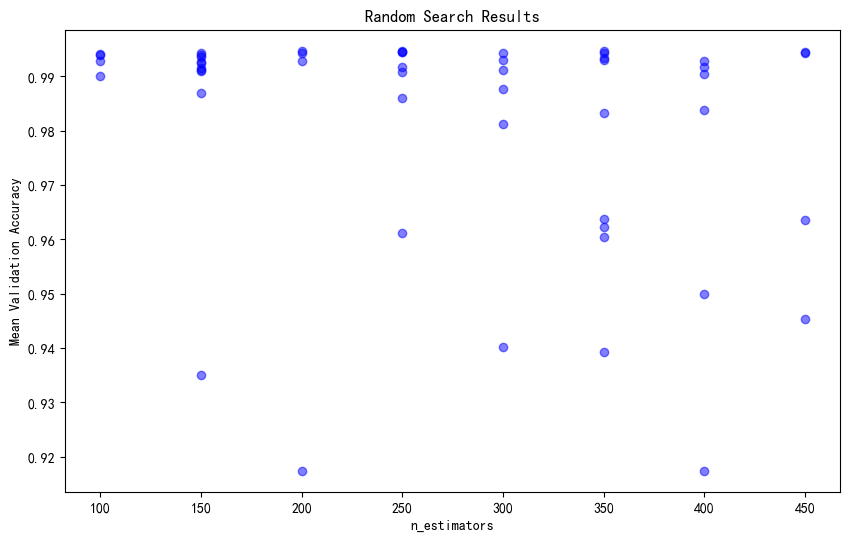

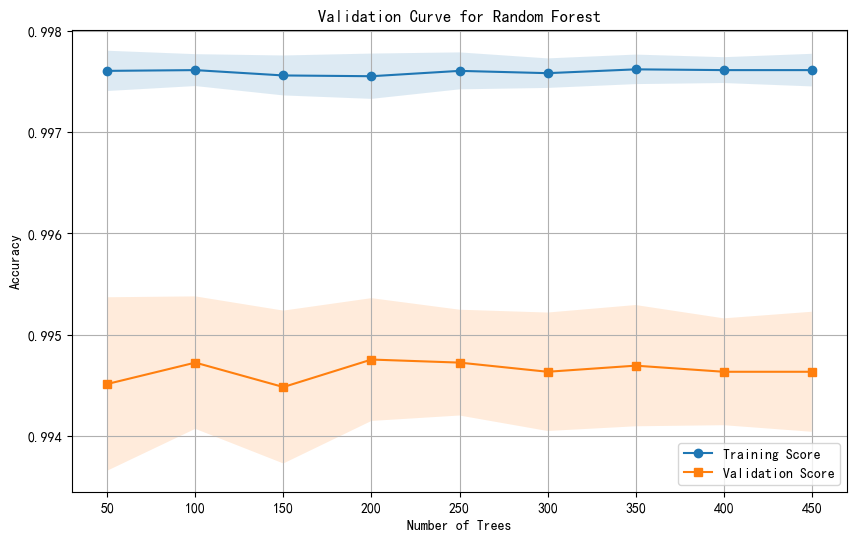


Optimized Model Evaluation:
Confusion Matrix:
[[7582   17]
 [  19  675]]
Classification Report:
              precision    recall  f1-score   support

           0   0.997500  0.997763  0.997632      7599
           1   0.975434  0.972622  0.974026       694

    accuracy                       0.995659      8293
   macro avg   0.986467  0.985193  0.985829      8293
weighted avg   0.995654  0.995659  0.995656      8293

Optimized Accuracy: 0.995659


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, validation_curve
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# 随机搜索调参
param_dist = {
    'n_estimators': np.arange(100, 500, 50),
    'max_depth': [None, 5, 10, 15, 20, 25],
    'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search.fit(X_train, y_train)

# 输出最佳参数
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Score: {:.6f}".format(random_search.best_score_))

# 随机搜索结果可视化（以n_estimators为例）
results = random_search.cv_results_
plt.figure(figsize=(10, 6))
plt.scatter(results['param_n_estimators'].data.astype(int), 
            results['mean_test_score'], 
            c='blue', alpha=0.5)
plt.xlabel('n_estimators')
plt.ylabel('Mean Validation Accuracy')
plt.title('Random Search Results')
plt.show()

# 验证曲线示例（n_estimators）
param_range = np.arange(50, 500, 50)
train_scores, test_scores = validation_curve(
    RandomForestClassifier(**random_search.best_params_, random_state=42),
    X_train,
    y_train,
    param_name='n_estimators',
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(param_range, np.mean(train_scores, axis=1), 'o-', label='Training Score')
plt.plot(param_range, np.mean(test_scores, axis=1), 's-', label='Validation Score')
plt.fill_between(param_range, 
                 np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                 np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                 alpha=0.15)
plt.fill_between(param_range,
                 np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
                 np.mean(test_scores, axis=1) + np.std(test_scores, axis=1),
                 alpha=0.15)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Validation Curve for Random Forest')
plt.legend()
plt.grid()
plt.show()

# 用最佳参数重新训练模型
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# 评估优化后的模型
print("\nOptimized Model Evaluation:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("Classification Report:")
print(classification_report(y_test, y_pred_best, digits=6))
print("Optimized Accuracy: {:.6f}".format(accuracy_score(y_test, y_pred_best)))

坐标轴意义：
坐标轴	含义
横轴 (X)	n_estimators：随机森林中决策树的数量
纵轴 (Y)	Mean Validation Accuracy：交叉验证的平均准确率
关键解读：
每个散点代表一个参数组合的实验结果

通过观察点的分布，可找到使准确率最高的树数量范围（例如图中250-350棵树时准确率较高）

坐标轴意义：
坐标轴	含义
横轴 (X)	Number of Trees：随机森林中决策树的数量 (n_estimators)
纵轴 (Y)	Accuracy：模型在训练集和验证集上的准确率
关键解读：
曲线类型	含义
Training Score (蓝色)	模型在训练集上的表现（反映过拟合风险）
Validation Score (橙色)	模型在验证集上的表现（反映泛化能力）
阴影区域	表示不同交叉验证折的分数波动范围（标准差）

典型分析结论：
随机搜索散点图：

当树数量较少时（左半区），模型可能欠拟合，准确率较低

当树数量过多时（右半区），准确率趋于稳定但计算成本增加

验证曲线：

训练分数始终高于验证分数 → 正常现象（模型在训练集表现更好）

如果两条曲线差距过大 → 可能过拟合（需调整正则化参数）

最佳参数位置：验证分数达到峰值时的树数量（图中约300棵树）

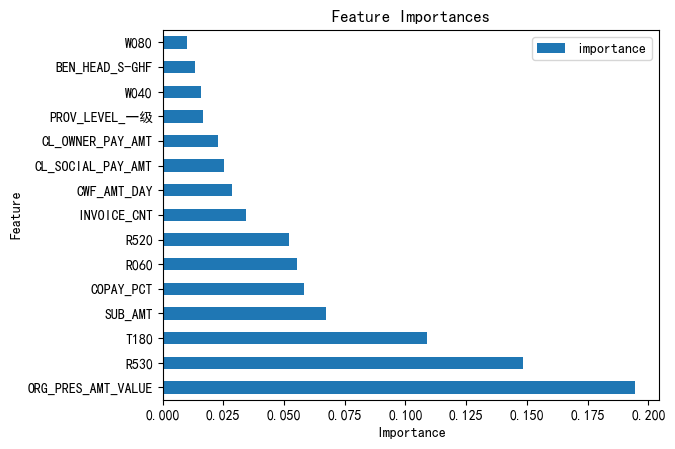

In [ ]:
# 画出特征重要性图（随机森林）
importances = pd.DataFrame({'feature':X.columns,'importance':np.round(model_RFC.feature_importances_,6)})
importances = importances.sort_values('importance',ascending=False).set_index('feature')
importances.head(15).plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

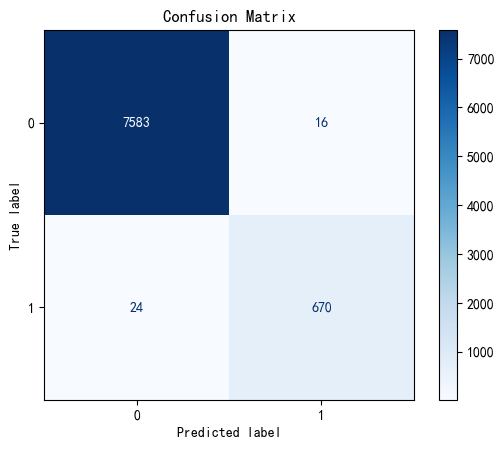

In [ ]:
# 画出混淆矩阵
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
# 预测
y_pred = model_RFC.predict(X_test)
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_RFC.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# MLP
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation
from keras.layers import LeakyReLU
from keras.layers import BatchNormalization

In [ ]:
model = Sequential()
model.add(Dense(128, input_shape=(234,)))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(LeakyReLU(negative_slope=0.05))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(units=64))
model.add(LeakyReLU(negative_slope=0.05))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(units=1,activation='sigmoid'))


d:\Anaconda\Anaconda3\envs\tensorflow-gpu\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        30,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,681 (155.00 KB)

 Trainable params: 39,041 (152.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
model.compile(loss='binary_crossentropy', 
              optimizer='adam', metrics=['accuracy'])
train_history =model.fit(x=X_train, 
                         y=y_train, 
                         validation_split=0.2, 
                         epochs=100, 
                         batch_size=100,verbose=2)

Epoch 1/100
266/266 - 2s - 7ms/step - accuracy: 0.7909 - loss: 0.4920 - val_accuracy: 0.9457 - val_loss: 0.1593
Epoch 2/100
266/266 - 1s - 2ms/step - accuracy: 0.9510 - loss: 0.1677 - val_accuracy: 0.9818 - val_loss: 0.0623
Epoch 3/100
266/266 - 1s - 2ms/step - accuracy: 0.9735 - loss: 0.0942 - val_accuracy: 0.9876 - val_loss: 0.0380
Epoch 4/100
266/266 - 1s - 2ms/step - accuracy: 0.9796 - loss: 0.0748 - val_accuracy: 0.9867 - val_loss: 0.0453
Epoch 5/100
266/266 - 1s - 2ms/step - accuracy: 0.9827 - loss: 0.0605 - val_accuracy: 0.9888 - val_loss: 0.0303
Epoch 6/100
266/266 - 1s - 2ms/step - accuracy: 0.9840 - loss: 0.0545 - val_accuracy: 0.9901 - val_loss: 0.0274
Epoch 7/100
266/266 - 1s - 2ms/step - accuracy: 0.9851 - loss: 0.0470 - val_accuracy: 0.9905 - val_loss: 0.0260
Epoch 8/100
266/266 - 1s - 2ms/step - accuracy: 0.9848 - loss: 0.0487 - val_accuracy: 0.9910 - val_loss: 0.0252
Epoch 9/100
266/266 - 1s - 2ms/step - accuracy: 0.9861 - loss: 0.0425 - val_accuracy: 0.9913 - val_loss:

In [ ]:
import matplotlib.pyplot as plt

def visu_train_history(train_history,train_metric,validation_metric):
    plt.plot(train_history.history[train_metric])
    plt.plot(train_history.history[validation_metric])
    plt.title('Train History')
    plt.ylabel(train_metric)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

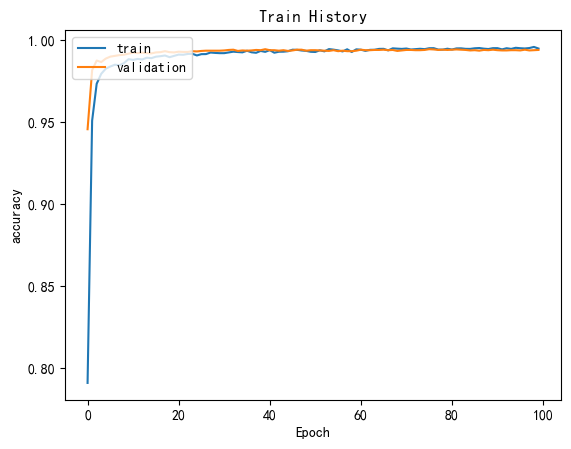

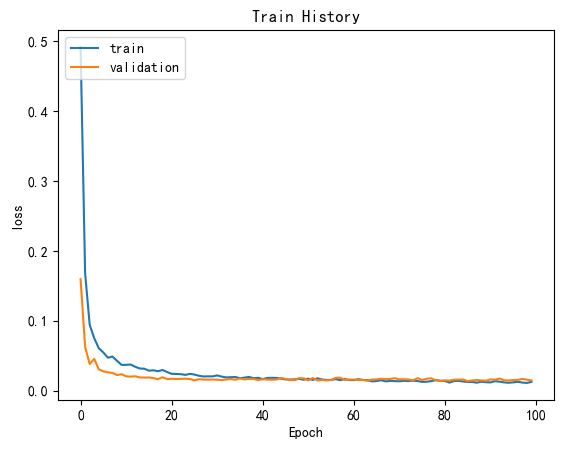

In [ ]:
visu_train_history(train_history,'accuracy','val_accuracy')
visu_train_history(train_history,'loss','val_loss')

In [ ]:
evaluate_result = model.evaluate(x=X_test, y=y_test)

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.9949 - loss: 0.0197


In [ ]:
evaluate_result

[0.01896379515528679, 0.9949355125427246]

In [ ]:
y_pred = model.predict(X_test)
y_pred=[y_pred>=0.5]
y_pred=y_pred[0].astype(int)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step
Confusion Matrix:
[[7580   19]
 [  23  671]]
Classification Report:
              precision    recall  f1-score   support

           0   0.996975  0.997500  0.997237      7599
           1   0.972464  0.966859  0.969653       694

    accuracy                       0.994935      8293
   macro avg   0.984719  0.982179  0.983445      8293
weighted avg   0.994924  0.994935  0.994929      8293

